# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [6]:
# откройте данные: 
import numpy as np
import pandas as pd
data = pd.read_csv('data/spam_or_not_spam.csv')
data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [7]:
# рассчитайте частоты для классов : 
spam_count = data['label'].value_counts().iloc[1]  # Количество спам-сообщений (label = 1)
not_spam_count = data['label'].value_counts().iloc[0]  # Количество не спам-сообщений (label = 0)

print(f"Количество спам-сообщений: {spam_count}")
print(f"Количество не спам-сообщений: {not_spam_count}")

Количество спам-сообщений: 500
Количество не спам-сообщений: 2500


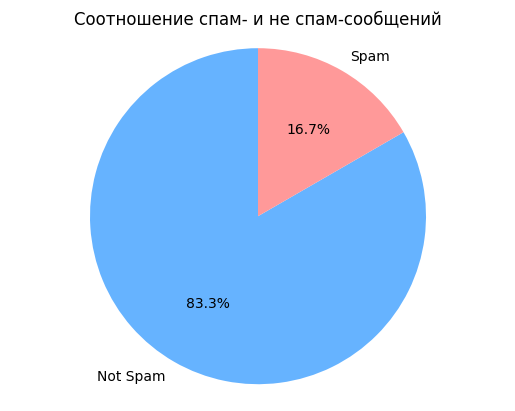

In [8]:
# визуализируйте результат: 
import matplotlib.pyplot as plt

labels = ['Not Spam', 'Spam']
sizes = [not_spam_count, spam_count]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.axis('equal')
plt.title('Соотношение спам- и не спам-сообщений')
plt.show()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [12]:
# Предобработка: замена пустых строк и строк из пробелов на NaN
data['email'] = data['email'].replace(r'^\s*$', np.nan, regex=True)

# Удаление строк с пропущенными значениями
data = data.dropna(subset=['email'])



Переводим данные в векторный вид:

In [13]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [14]:
# Количество признаков после векторизации
num_features = X.shape[1]
print(f"Количество признаков после предобработки: {num_features}")

Количество признаков после предобработки: 34116


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [15]:
# Определение целевой переменной и признаков
X = vectorizer.fit_transform(data['email'])
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [17]:
# Разделение выборки на обучающую и тестовую
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [18]:
# Вычисление среднего значения целевой переменной для тестовой выборки
mean_y_test = y_test.mean()
print(f"Среднее значение целевой переменной для тестовой выборки: {mean_y_test:.3f}")

Среднее значение целевой переменной для тестовой выборки: 0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
# Обучение модели
clf = MultinomialNB(alpha=0.01)
clf.fit(X_train, y_train)
# Предсказания
y_pred = clf.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [21]:
# Оценка метрик
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

Accuracy: 0.987
Precision: 1.000
Recall: 0.919


Нарисуйте ROC-кривую:

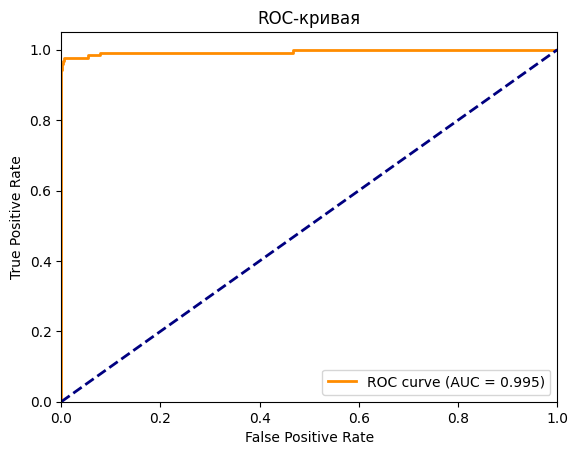

In [22]:
# Построение ROC-кривой
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [25]:
from sklearn.model_selection import cross_val_score

# Перебор значений alpha
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
results = []

for alpha in alphas:
    # Инициализация модели
    clf = MultinomialNB(alpha=alpha)
    # Кросс-валидация с 5 фолдами
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    # Средняя точность и стандартное отклонение
    mean_score = scores.mean()
    std_score = scores.std()
    results.append((alpha, mean_score, std_score))
    print(f"Alpha: {alpha:.3f}, Средняя точность: {mean_score:.3f}, Станд. отклонение: {std_score:.3f}")

# Оценка зависимости качества от alpha
best_alpha = max(results, key=lambda x: x[1])[0]
print(f"\nЛучшее значение alpha: {best_alpha}")

Alpha: 0.001, Средняя точность: 0.987, Станд. отклонение: 0.006
Alpha: 0.010, Средняя точность: 0.989, Станд. отклонение: 0.003
Alpha: 0.100, Средняя точность: 0.992, Станд. отклонение: 0.003
Alpha: 0.500, Средняя точность: 0.991, Станд. отклонение: 0.002
Alpha: 1.000, Средняя точность: 0.991, Станд. отклонение: 0.002
Alpha: 2.000, Средняя точность: 0.984, Станд. отклонение: 0.005

Лучшее значение alpha: 0.1
